In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
import pickle

In [2]:
df = pd.read_csv("cleaned_data.csv")

In [3]:
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel


In [4]:
df['name'].unique()

array(['Hyundai Santro Xing', 'Mahindra Jeep CL550', 'Hyundai Grand i10',
       'Ford EcoSport Titanium', 'Ford Figo', 'Hyundai Eon',
       'Ford EcoSport Ambiente', 'Maruti Suzuki Alto',
       'Skoda Fabia Classic', 'Maruti Suzuki Stingray',
       'Hyundai Elite i20', 'Mahindra Scorpio SLE', 'Audi A8', 'Audi Q7',
       'Mahindra Scorpio S10', 'Hyundai i20 Sportz',
       'Maruti Suzuki Vitara', 'Mahindra Bolero DI',
       'Maruti Suzuki Swift', 'Maruti Suzuki Wagon', 'Toyota Innova 2.0',
       'Renault Lodgy 85', 'Skoda Yeti Ambition', 'Maruti Suzuki Baleno',
       'Renault Duster 110', 'Renault Duster 85', 'Honda City 1.5',
       'Maruti Suzuki Dzire', 'Honda Amaze', 'Honda Amaze 1.5',
       'Honda City', 'Datsun Redi GO', 'Maruti Suzuki SX4',
       'Mitsubishi Pajero Sport', 'Honda City ZX', 'Tata Indigo eCS',
       'Volkswagen Polo Highline', 'Chevrolet Spark LS',
       'Renault Duster 110PS', 'Mini Cooper S', 'Skoda Fabia 1.2L',
       'Renault Duster', 'Mahindra Scor

C:\Users\pratham shukla\AppData\Local\Temp\ipykernel_23376\708458291.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Price'])


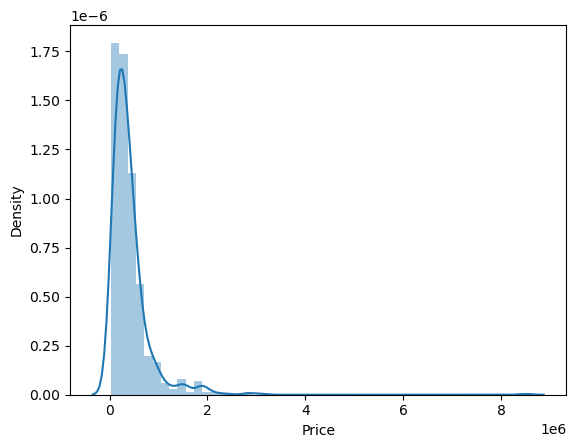

In [5]:
sns.distplot(df['Price'])
plt.show()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    object
 2   year        816 non-null    int64 
 3   Price       816 non-null    int64 
 4   kms_driven  816 non-null    int64 
 5   fuel_type   816 non-null    object
dtypes: int64(3), object(3)
memory usage: 38.4+ KB


C:\Users\pratham shukla\AppData\Local\Temp\ipykernel_23376\1810275633.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['year'])


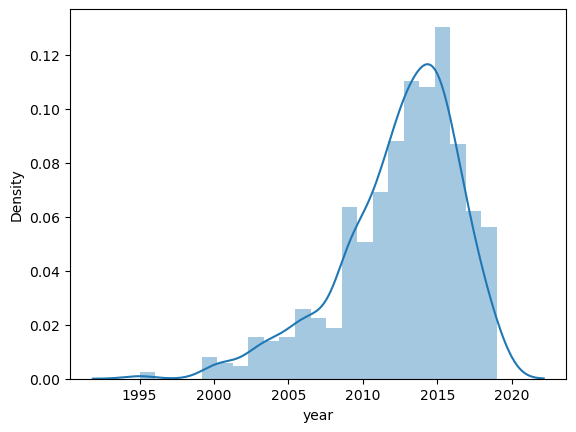

In [7]:
sns.distplot(df['year'])
plt.show()

In [8]:
df1 = df.copy()

In [9]:
df1=df1[df1['Price']<6e6]

In [10]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 815 entries, 0 to 815
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        815 non-null    object
 1   company     815 non-null    object
 2   year        815 non-null    int64 
 3   Price       815 non-null    int64 
 4   kms_driven  815 non-null    int64 
 5   fuel_type   815 non-null    object
dtypes: int64(3), object(3)
memory usage: 44.6+ KB


In [11]:
numerical = ['year','kms_driven']
categorical = ['name','company','fuel_type']

In [12]:
preprocessor = ColumnTransformer(
    transformers = [
        ('numerical',StandardScaler(),numerical),
        ('categorical',OneHotEncoder(handle_unknown='ignore'),categorical)
    ],
    remainder='passthrough'
)

In [13]:
pipeline = Pipeline(steps=[
    ("Preprocessor",preprocessor),
    ("Regressor",LinearRegression()
)
])

In [14]:
X = df1.drop('Price', axis=1)
y = df1['Price']

In [15]:
y = np.log1p(y)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=441)

In [17]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical', StandardScaler(),
                                                  ['year', 'kms_driven']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('Regressor', LinearRegression())])

In [18]:
pipeline.score(X_test,y_test)

0.8754022399815968

In [19]:
scores = []
for i in range(1000):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    pipeline.fit(X_train,y_train)
    scores.append(pipeline.score(X_test,y_test))

In [20]:
np.argmax(scores)

np.int64(441)

In [21]:
from sklearn.model_selection import cross_val_score

# Use your main 'X' and 'y' data (before the train_test_split)
# Use your 'pipe' (the pipeline with the preprocessor and model)
# 'cv=5' means 5-fold cross-validation
scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')

print(f"R2 scores for each fold: {scores}")
print(f"Average R2 score: {scores.mean()}")

R2 scores for each fold: [0.51738236 0.83073383 0.7485914  0.76826778 0.73695957]
Average R2 score: 0.7203869865371424


In [22]:
with open("car_price_model.pkl", "wb") as f:
    pickle.dump(pipeline, f)

In [23]:
print(X.columns)

Index(['name', 'company', 'year', 'kms_driven', 'fuel_type'], dtype='object')


In [24]:
print(type(pipeline))

<class 'sklearn.pipeline.Pipeline'>
